In [1]:
# import libraries
import math

import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
import itertools

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import random
import time

# import Koopman Libraries
from core.koopman_core_linear import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
# from core.koopman_linear_time_delay import KoopDNN, KoopmanNet, KoopmanNetCtrl
from sklearn import preprocessing
from core.util import fit_standardizer
# from models.koop_model import model_matricies,lift
from models.koop_model import model_matricies, lift_raw, lift_scaled



# Import Adaptive Koopman
from core.adapt_net_linear import AdaptNet_linear
import scipy.io
import importlib
import dynamics.caca as caca
importlib.reload(caca)

# from dynamics.sync_pendulum import sync_pendulum_data_gen_multi, FK_solver

# from dynamics.sync_pendulum import FK_solver, single_vehicle_data_gen_multi
from dynamics.caca import FK_solver, single_vehicle_data_gen_multi

Using device: cuda
GPU: NVIDIA GeForce RTX 5080


## 系统拟合

In [2]:
"""Choose the type of Koopman representation"""
linear = True

## 数据生成

In [3]:
# define system pars
sys_pars = {}

num_states = 5
num_inputs = 2
dt = 0.02

sys_pars['num_states'] = num_states
sys_pars['num_inputs'] = num_inputs
sys_pars['dt'] = dt

# vehicle parameters
sys_pars['m'] = 1500.0
sys_pars['Iz'] = 2250.0
sys_pars['lf'] = 1.2
sys_pars['lr'] = 1.6
sys_pars['Cf'] = 80000.0
sys_pars['Cr'] = 80000.0
sys_pars['vx_ref'] = 5.0
sys_pars['curvature_ref'] = 0.0

# input generation
sys_pars['U_type'] = 'sinusoidal'
# sys_pars['delta_max'] = 0.03
sys_pars['delta_max'] = 0.05

sys_pars['ax_max'] = 0.6

# uncertainty setting
sys_pars['uncertainty'] = 'NA'
sys_pars['amp'] = 0.0
sys_pars['freq'] = 1.0

In [4]:
sys_pars_new = {}

sys_pars_new['num_states'] = num_states
sys_pars_new['num_inputs'] = num_inputs
sys_pars_new['dt'] = dt

# changed vehicle parameters
sys_pars_new['m'] = 1650.0
sys_pars_new['Iz'] = 2400.0
sys_pars_new['lf'] = 1.2
sys_pars_new['lr'] = 1.6
sys_pars_new['Cf'] = 70000.0
sys_pars_new['Cr'] = 70000.0
sys_pars_new['vx_ref'] = 8.0
sys_pars_new['curvature_ref'] = 0.0

sys_pars_new['U_type'] = sys_pars['U_type']
sys_pars_new['delta_max'] = sys_pars['delta_max']
sys_pars_new['ax_max'] = sys_pars['ax_max']

sys_pars_new['uncertainty'] = 'periodic'
sys_pars_new['amp'] = 0.02
sys_pars_new['freq'] = 1.0

sensor_noise = False
SNR_DB = 30


In [5]:
num_traj = 400
num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

num_snaps = 200

X, X_changed, U = single_vehicle_data_gen_multi(
    num_traj, num_snaps, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)
print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)


X shape: (400, 200, 5)
X_changed shape: (400, 200, 5)
U shape: (400, 199, 2)


In [6]:
import os
import pickle

os.makedirs("saved_data/single_vehicle", exist_ok=True)

# 1) 保存轨迹数组
np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

# 2) 保存参数字典
with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

离线数据已保存。


In [7]:
if sys_pars_new['uncertainty'] == 'constant':
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/constant/sensor noise/'+ str(sys_pars_new['amp'])+ '/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/constant/no sensor noise/'+ str(sys_pars_new['amp'])
elif sys_pars_new['uncertainty'] == 'periodic':
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/periodic/sensor noise/'+ str(sys_pars_new['freq'])+ '/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/periodic/no sensor noise/'+ str(sys_pars_new['freq'])
else:
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/parametric/sensor_noise/'+str(percent_change) +'/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/parametric/no_sensor_noise/'+str(percent_change)

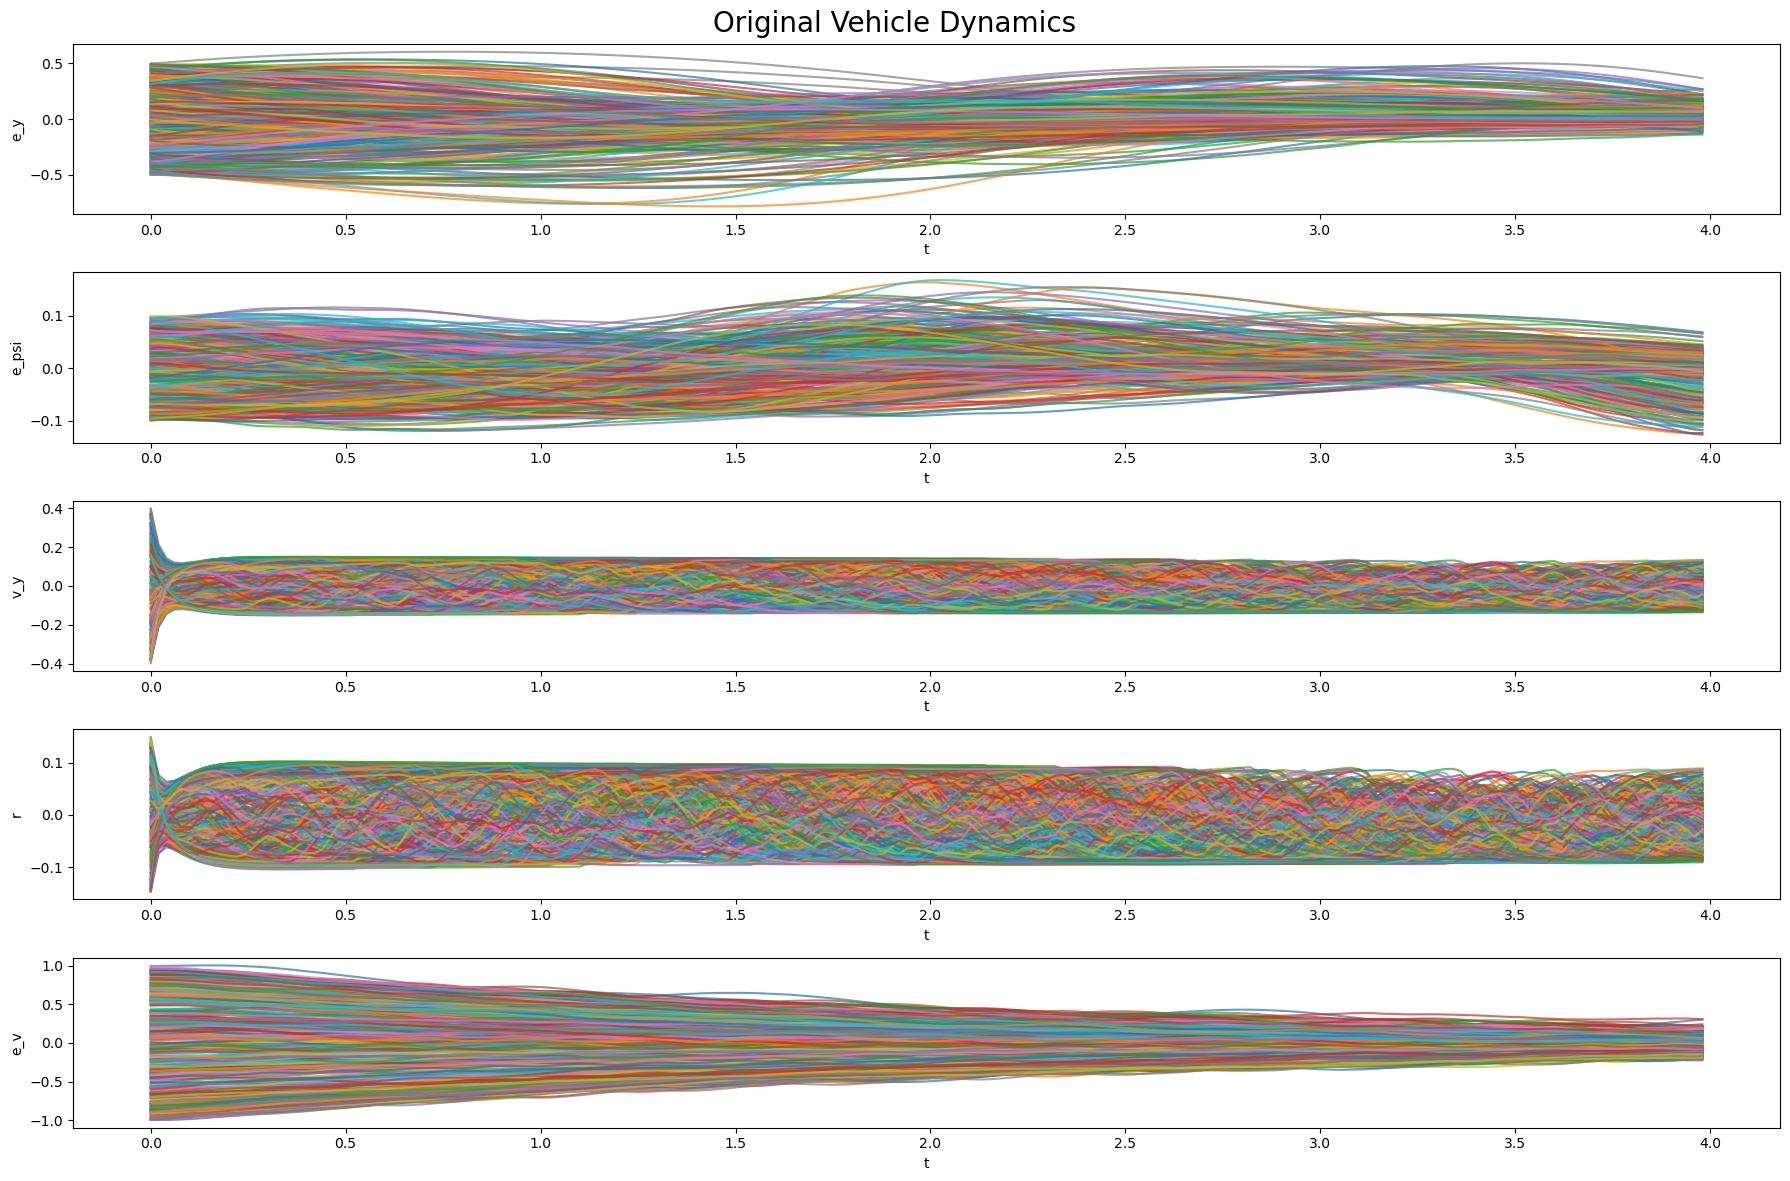

In [8]:
state_labels = ['e_y', 'e_psi', 'v_y', 'r', 'e_v']
input_labels = ['delta', 'a_x']
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

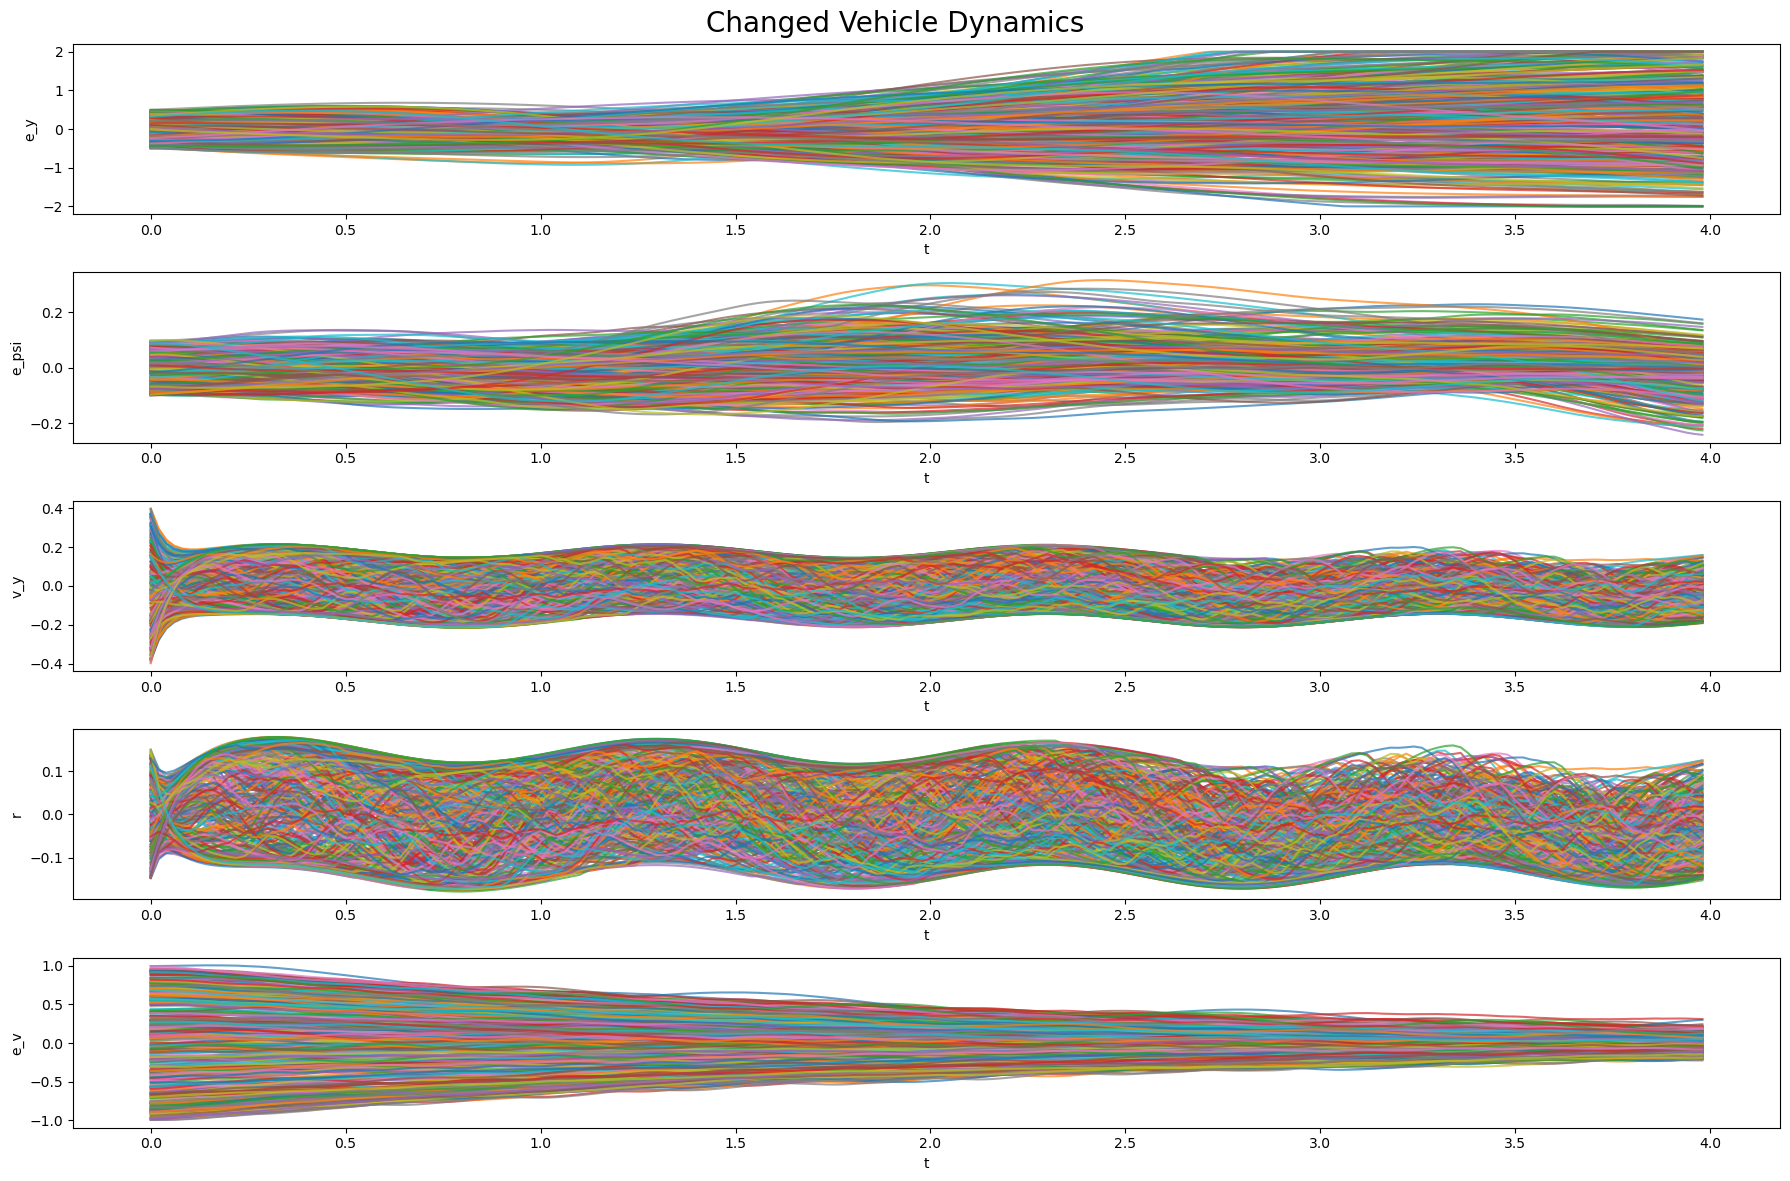

In [9]:
plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

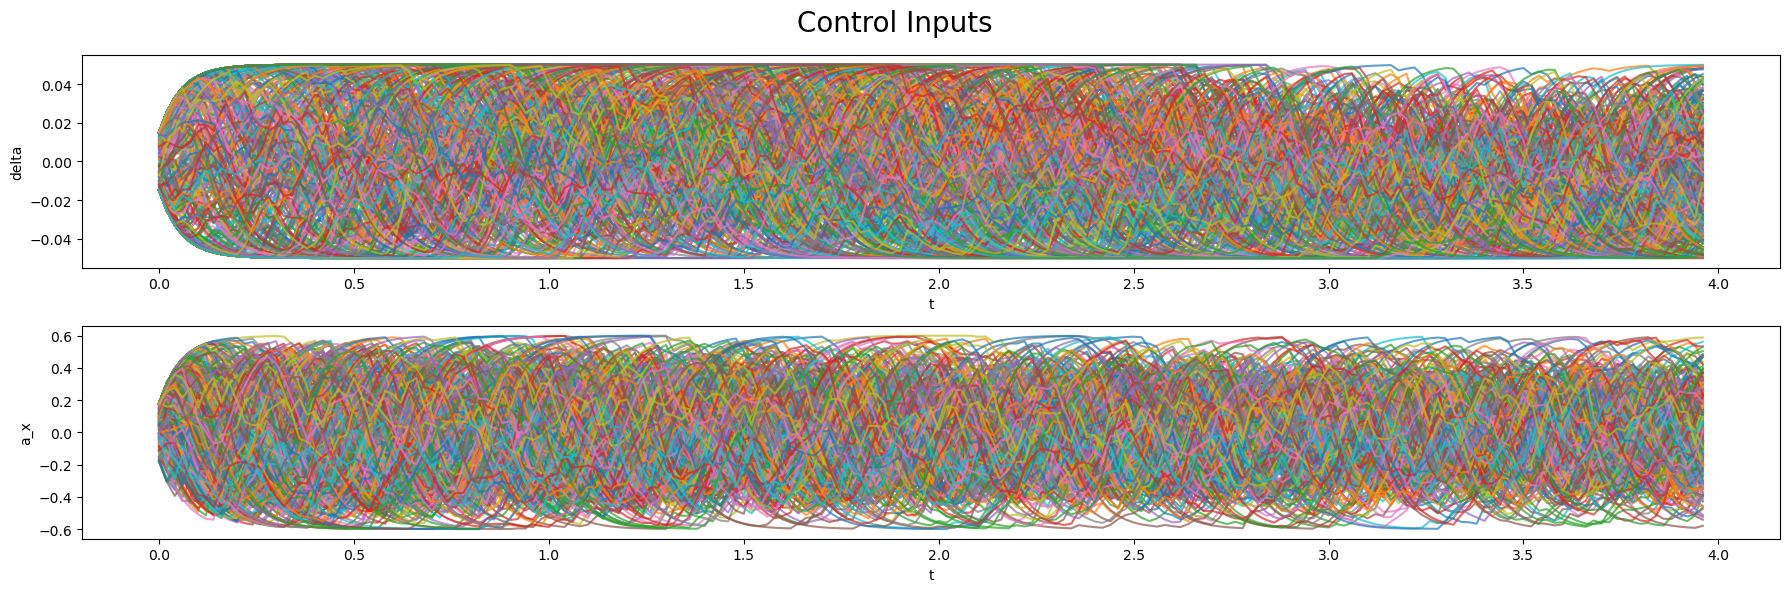

In [10]:
plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

## Learning Koopman 生成拟合模型

In [11]:
# split training and vaidation datasets
xs_train, us_train = X[:num_train,:,:],U[:num_train,:,:]
xs_val, us_val = X[num_train:,:,:],U[num_train:,:,:]

xs_train.shape, us_train.shape

((320, 200, 5), (320, 199, 2))

In [12]:
net_params_lin = {}
net_params_lin['state_dim'] = num_states
net_params_lin['ctrl_dim'] = num_inputs
net_params_lin['encoder_hidden_width'] = 128
net_params_lin['encoder_hidden_depth'] = 3
net_params_lin['encoder_output_dim'] = 16
net_params_lin['optimizer'] = 'adam'
net_params_lin['activation_type'] = 'tanh'
net_params_lin['lr'] = 2e-4
net_params_lin['epochs'] = 300
net_params_lin['batch_size'] = 256

net_params_lin['eig_loss'] = True
net_params_lin['eig_loss_coeff'] = 1.0
net_params_lin['lifted_loss_penalty'] = 1.0

net_params_lin['l2_reg'] = 1e-5
net_params_lin['l1_reg'] = 1e-7
net_params_lin['first_obs_const'] = True
net_params_lin['override_C'] = True
net_params_lin['dt'] = dt

In [13]:
import os

train = True
standardize = True

os.makedirs('saved_models/single_vehicle/linear', exist_ok=True)

file_koop_linear = (
    'saved_models/single_vehicle/linear/'
    + 'Koop_vehicle_Dim'
    + str(net_params_lin['encoder_output_dim'])
    + '_dt_'
    + str(dt)
    + '.pth'
)

file_koop_linear

'saved_models/single_vehicle/linear/Koop_vehicle_Dim16_dt_0.02.pth'

In [14]:
standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

In [15]:
if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE
print("Model parameter device:", next(model_koop_dnn_lin.net.parameters()).device)

Epoch   1: train loss: 0.8371161909, validation loss: 0.7422916700
Epoch   2: train loss: 0.6637617816, validation loss: 0.6732849157
Epoch   3: train loss: 0.6042350192, validation loss: 0.6193084963
Epoch   4: train loss: 0.5554921980, validation loss: 0.5735120021
Epoch   5: train loss: 0.5137559919, validation loss: 0.5328729157
Epoch   6: train loss: 0.4775953326, validation loss: 0.4979577755
Epoch   7: train loss: 0.4469911436, validation loss: 0.4681680117
Epoch   8: train loss: 0.4223431865, validation loss: 0.4442769019
Epoch   9: train loss: 0.4009872349, validation loss: 0.4247319476
Epoch  10: train loss: 0.3833591689, validation loss: 0.4079474473
Epoch  11: train loss: 0.3677198089, validation loss: 0.3917597057
Epoch  12: train loss: 0.3533078925, validation loss: 0.3776569556
Epoch  13: train loss: 0.3399308166, validation loss: 0.3612850036
Epoch  14: train loss: 0.3270115143, validation loss: 0.3499723219
Epoch  15: train loss: 0.3145897300, validation loss: 0.335981

In [16]:

# if train == True:
#     if standardize:
#         net = KoopmanNetCtrl_linear(net_params_lin, standardizer_x=standardizer_x_kdnn, standardizer_u=standardizer_u_kdnn)
#     else:
#         net = KoopmanNetCtrl_linear(net_params_lin)
#     model_koop_dnn_lin = KoopDNN_linear(net)
#     model_koop_dnn_lin.set_datasets(xs_train, u_train=us_train, x_val=xs_val, u_val=us_val)
#     model_koop_dnn_lin.model_pipeline(net_params_lin)
#     model_koop_dnn_lin.construct_koopman_model()
#     torch.save(model_koop_dnn_lin,file_koop_linear)
# else:
    # model_koop_dnn_lin = torch.load(file_koop_linear, weights_only=True)

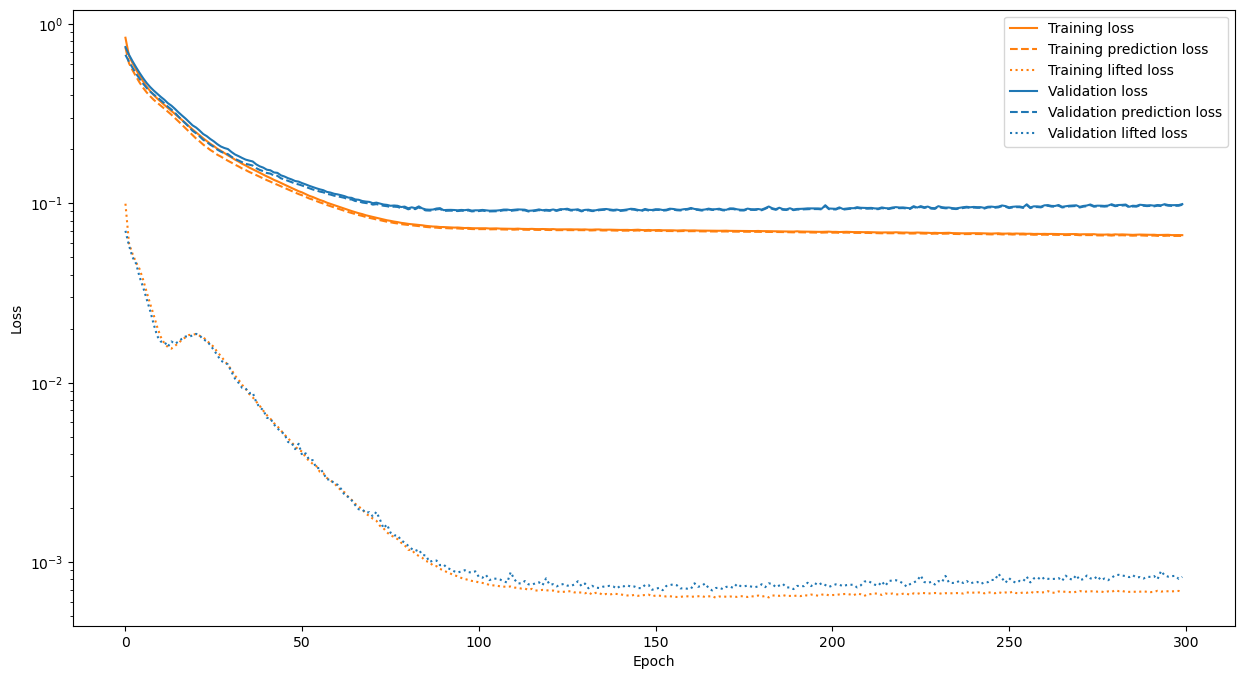

In [17]:
train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin['epochs'])

plt.figure(figsize=(15,8))
plt.plot(epochs, train_loss, color='tab:orange', label='Training loss')
plt.plot(epochs, train_pred_loss, '--', color='tab:orange', label='Training prediction loss')
plt.plot(epochs, train_lifted_loss, ':', color='tab:orange', label='Training lifted loss')
plt.plot(epochs, val_loss, color='tab:blue', label='Validation loss')
plt.plot(epochs, val_pred_loss, '--', color='tab:blue', label='Validation prediction loss')
plt.plot(epochs, val_lifted_loss, ':', color='tab:blue', label='Validation lifted loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.show()

## Koopman Model Parameters

In [18]:
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1 # no. of training examples
first_obs_const = int(net_params_lin['first_obs_const']) #only one state
override_C = net_params_lin['override_C']
if override_C:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + first_obs_const

In [19]:
x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

In [20]:
x_unchanged_test.shape, x_changed_test.shape, u_test.shape

((1, 100, 5), (1, 100, 5), (1, 99, 2))

stable spectral radius = 0.9990002
(22, 22) (22, 2) (5, 22)
spectral radius = 1.0173283
eigvals = [0.33457336+0.j         0.44127968+0.j         0.9263625 +0.j
 0.98645747+0.03070311j 0.98645747-0.03070311j 0.98658544+0.02430341j
 0.98658544-0.02430341j 1.0173283 +0.j         0.9882998 +0.01217522j
 0.9882998 -0.01217522j 1.0079446 +0.j         0.9926803 +0.00844988j
 0.9926803 -0.00844988j 0.9943122 +0.00556625j 0.9943122 -0.00556625j
 0.99130756+0.j         0.9925118 +0.00145867j 0.9925118 -0.00145867j
 0.9955322 +0.j         0.9994105 +0.j         0.99999964+0.j
 1.        +0.j        ]


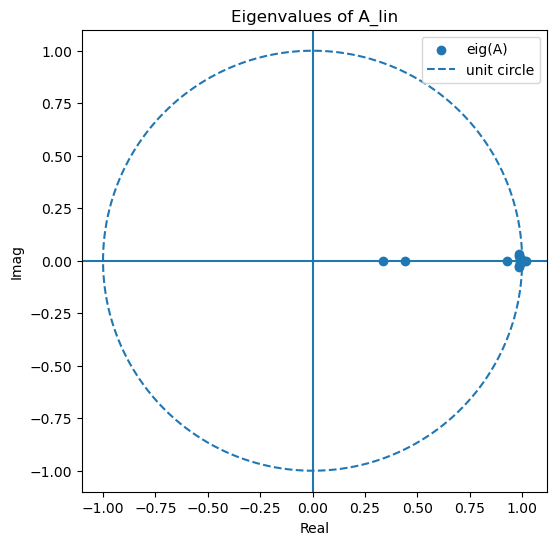

In [21]:
A_lin = np.array(model_koop_dnn_lin.A)
B_lin = np.array(model_koop_dnn_lin.B)
C_lin = np.array(model_koop_dnn_lin.C)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([ev / max(1.0, np.abs(ev)) * 0.999 for ev in eigvals])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print(A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label='eig(A)')
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), '--', label='unit circle')
plt.axhline(0)
plt.axvline(0)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.legend()
plt.title('Eigenvalues of A_lin')
plt.axis('equal')
plt.show()


# X_unchanged,_ = model_koop_dnn_lin.net.process(x_unchanged_test,data_u = u_test)



In [22]:
# X_unchanged.shape, X_changed.shape

In [23]:
# x_unchanged = X_unchanged[:, :num_states]
X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)

# X_changed,_ = model_koop_dnn_lin.net.process(x_changed_test,data_u = u_test)

X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]

# u = X_unchanged[:, num_states:num_states+num_inputs]

u_scaled = X_unchanged_scaled[:, num_states:num_states+num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states+num_inputs:]
# x_unchanged_prime = X_unchanged[:,num_states+num_inputs:]

# x_changed = X_changed[:, :num_states]
# x_changed_prime = X_changed[:,num_states+num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states+num_inputs:]


In [24]:
# x_changed.shape, x_changed_prime.shape, x_unchanged_scaled.shape
x_changed_scaled.shape, x_changed_prime_scaled.shape, x_unchanged_scaled.shape


((99, 5), (99, 5), (99, 5))

x_unchanged_scaled shape: (99, 5)
u_scaled shape: (99, 2)


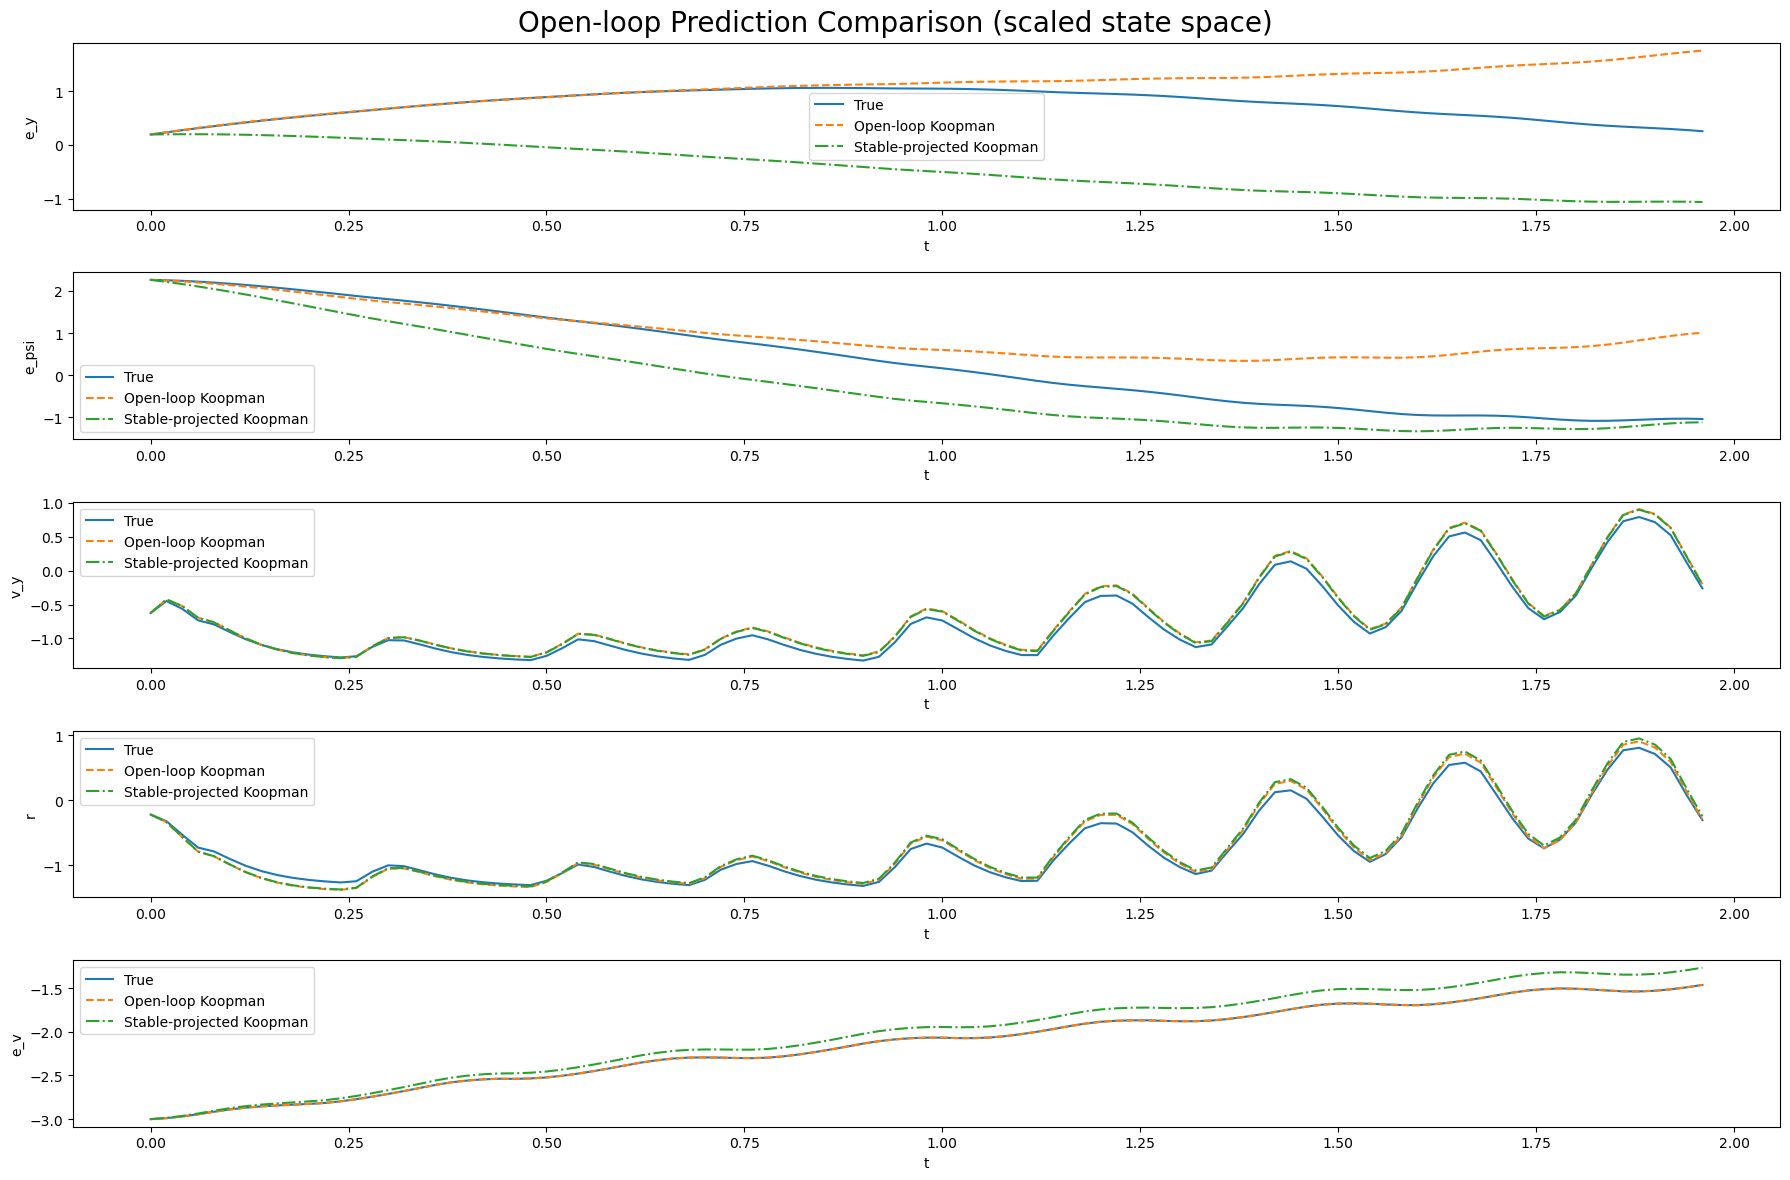

In [25]:
# print("x_unchanged shape:", x_unchanged_scaled.shape)
# print("u_scaled shape:", u_scaled.shape)

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

# z_lin[0, :] = lift(x_unchanged[0, :], model_koop_dnn_lin, net_params_lin)
z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)

x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label='True')
    plt.plot(T_plot, x_est_lin[:, i], '--', label='Open-loop Koopman')
    plt.plot(T_plot, x_est_lin_stable[:, i], '-.', label='Stable-projected Koopman')
    plt.legend()

# plt.suptitle("Open-loop Prediction Comparison", fontsize=20)
plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)

plt.tight_layout()
plt.show()

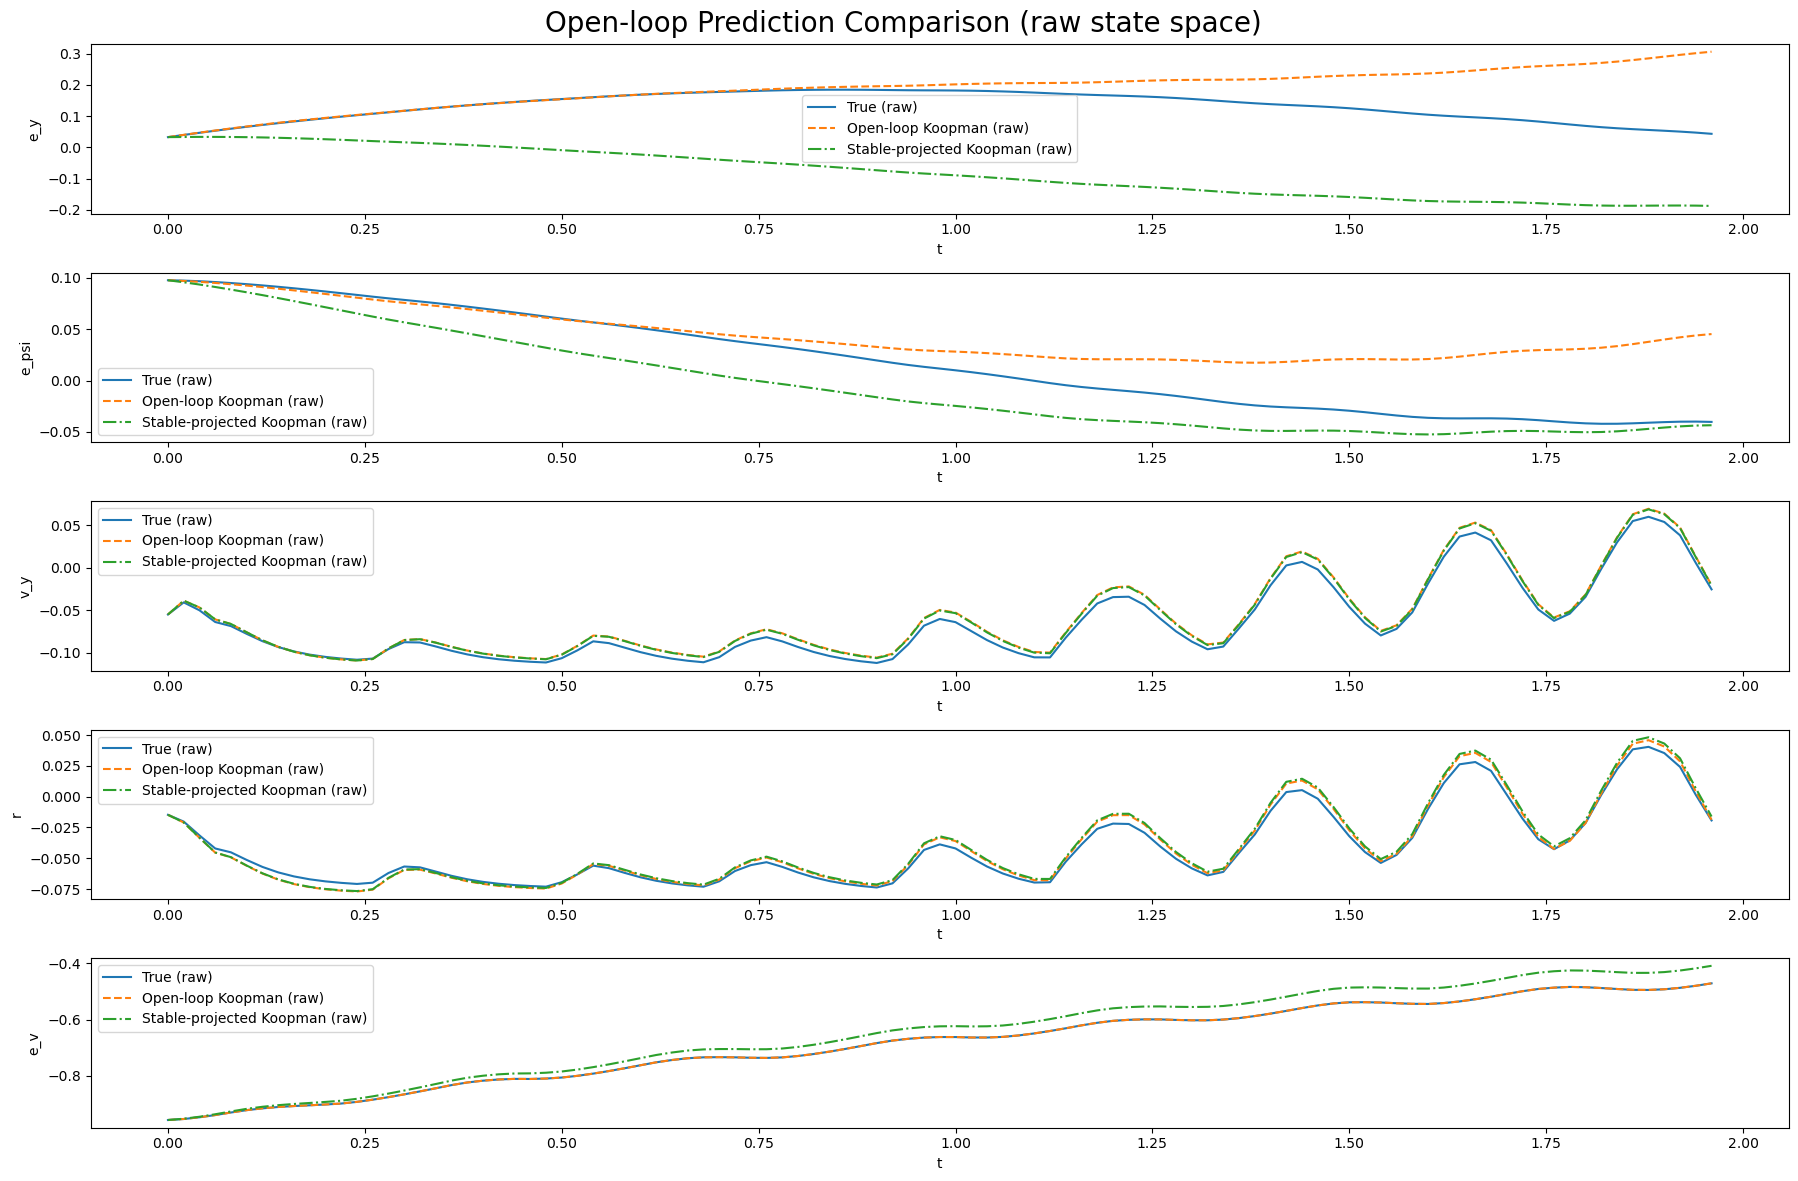

In [26]:
x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label='True (raw)')
    plt.plot(T_plot, x_est_lin_raw[:, i], '--', label='Open-loop Koopman (raw)')
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], '-.', label='Stable-projected Koopman (raw)')
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

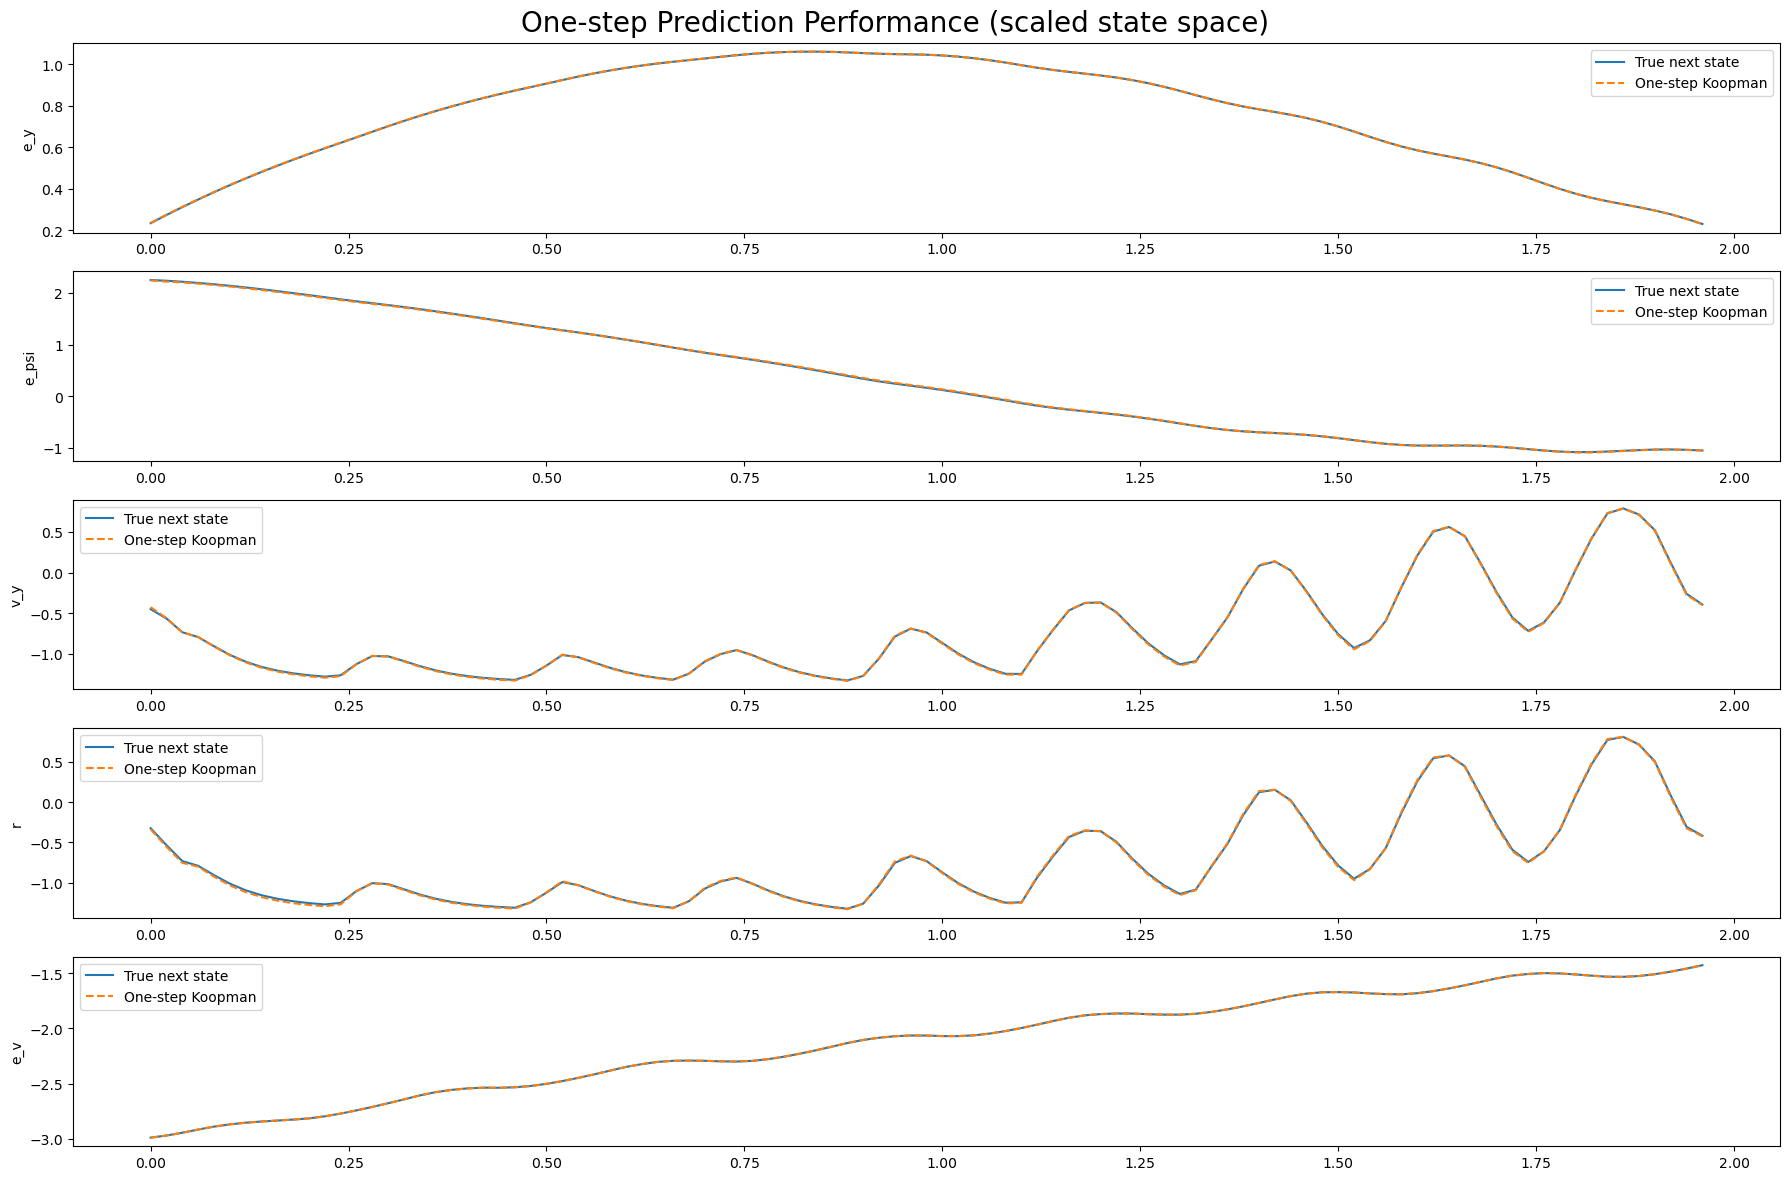

In [27]:
T_plot = np.arange(num_pred) * dt


# x_one_step = np.zeros_like(x_unchanged)
# x_one_step[0, :] = x_unchanged[0, :]
#
# for k in range(num_pred - 1):
#     z_k = lift_scaled(x_unchanged[k, :], model_koop_dnn_lin, net_params_lin)
#     z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u[k, :], B_lin.T)
#     x_one_step[k + 1, :] = np.matmul(z_k1, C_lin.T)

# x_one_step_pred = np.zeros_like(x_unchanged_prime)
#
# for k in range(num_pred):
#     z_k = lift_scaled(x_unchanged[k, :], model_koop_dnn_lin, net_params_lin)
#     z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u[k, :], B_lin.T)
#     x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)
#
# T_plot_1 = np.arange(x_one_step_pred.shape[0]) * dt
#
# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.plot(T_plot_1, x_unchanged_prime[:, i], label='True next state')
#     plt.plot(T_plot_1, x_one_step_pred[:, i], '--', label='One-step Koopman')
#     plt.ylabel(state_labels[i])
#     plt.legend()
# plt.suptitle("One-step Prediction Performance", fontsize=20)
# plt.tight_layout()
# plt.show()


x_one_step_pred = np.zeros_like(x_unchanged_prime_scaled)

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(x_one_step_pred.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_1, x_unchanged_prime_scaled[:, i], label='True next state')
    plt.plot(T_plot_1, x_one_step_pred[:, i], '--', label='One-step Koopman')
    plt.ylabel(state_labels[i])
    plt.legend()
# plt.suptitle("One-step Prediction Performance", fontsize=20)
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)


plt.tight_layout()
plt.show()



# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.plot(T_plot, x_unchanged[:, i], label='True')
#     plt.plot(T_plot, x_one_step[:, i], '--', label='One-step Koopman')
#     plt.ylabel(state_labels[i])
#     plt.legend()
# plt.suptitle("One-step Prediction Performance", fontsize=20)
# plt.tight_layout()
# plt.show()

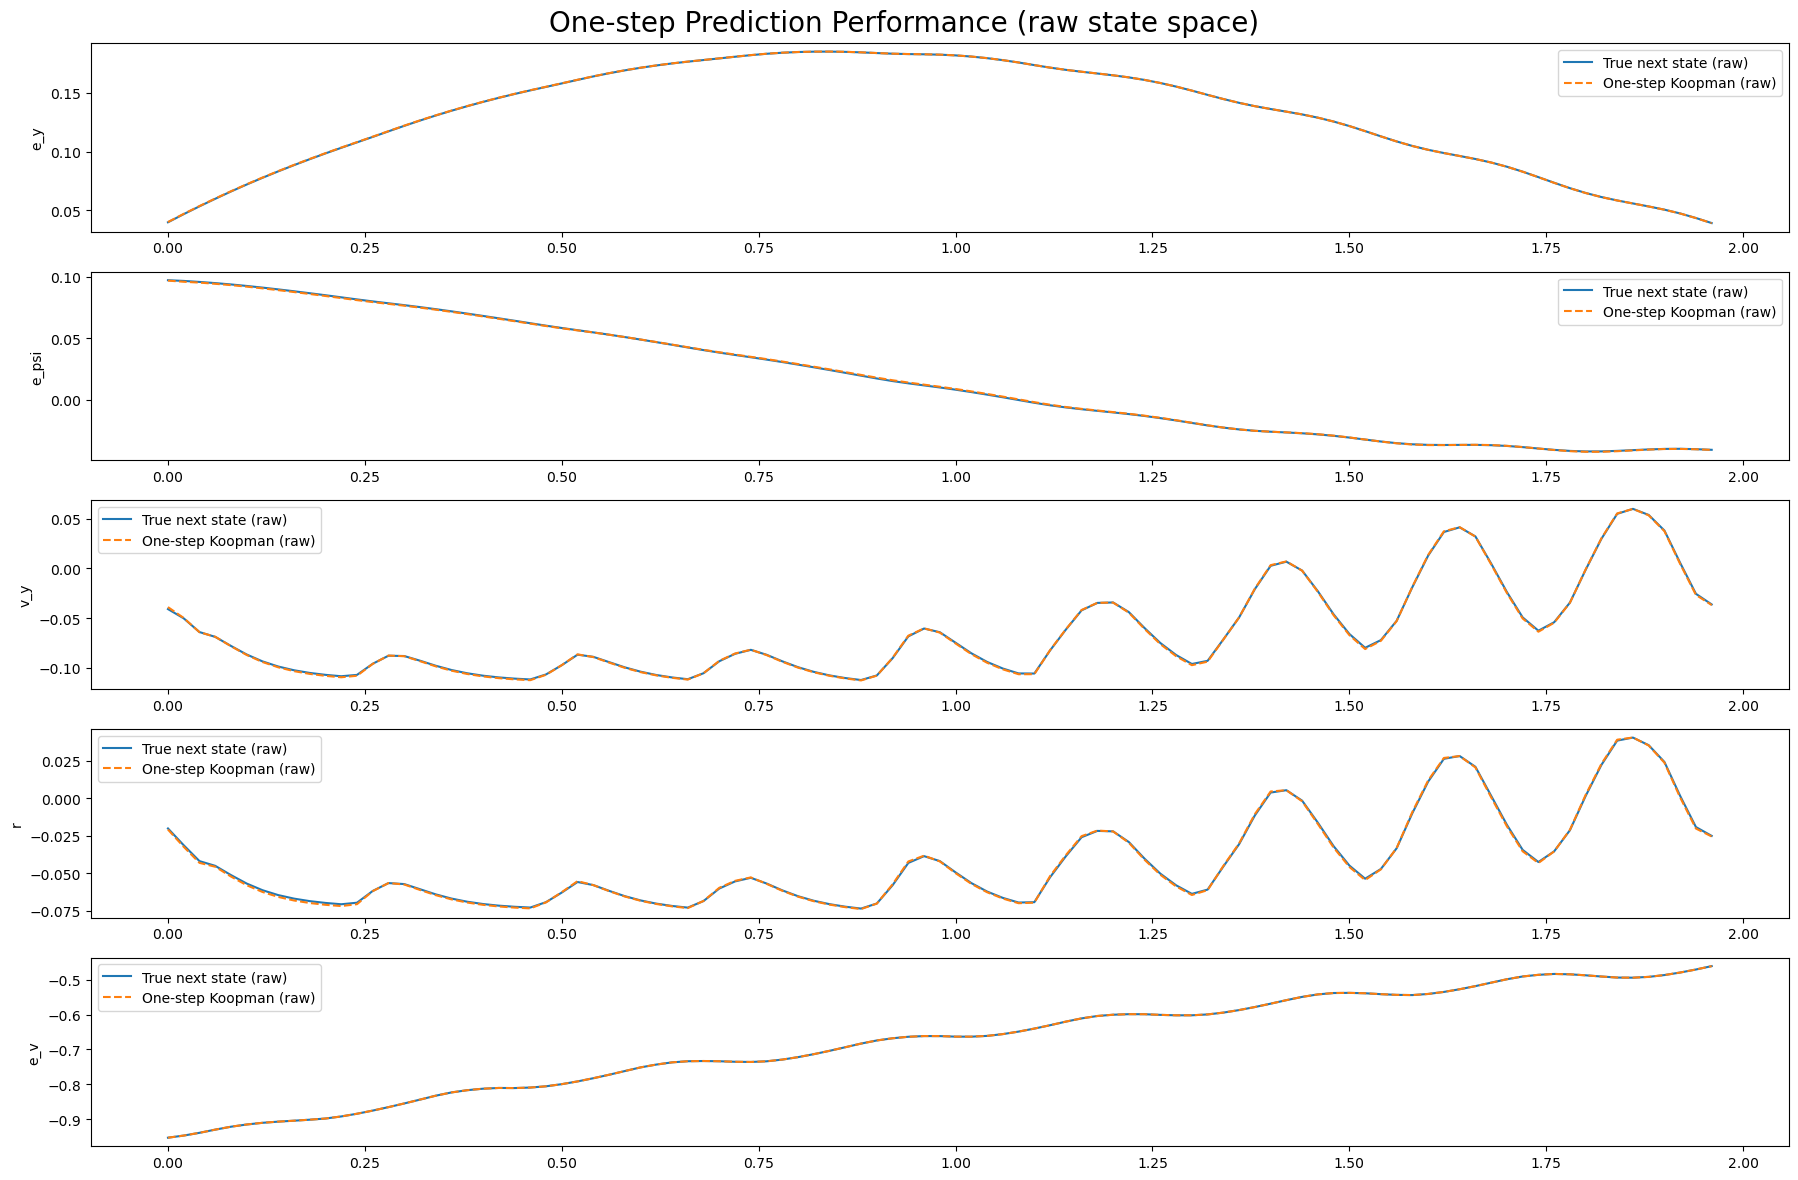

In [28]:
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)
x_true_next_raw = x_unchanged_test[0, 1:, :]

T_plot_raw = np.arange(x_true_next_raw.shape[0]) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label='True next state (raw)')
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], '--', label='One-step Koopman (raw)')
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

## Testing

## Adaptive Koopman with Control

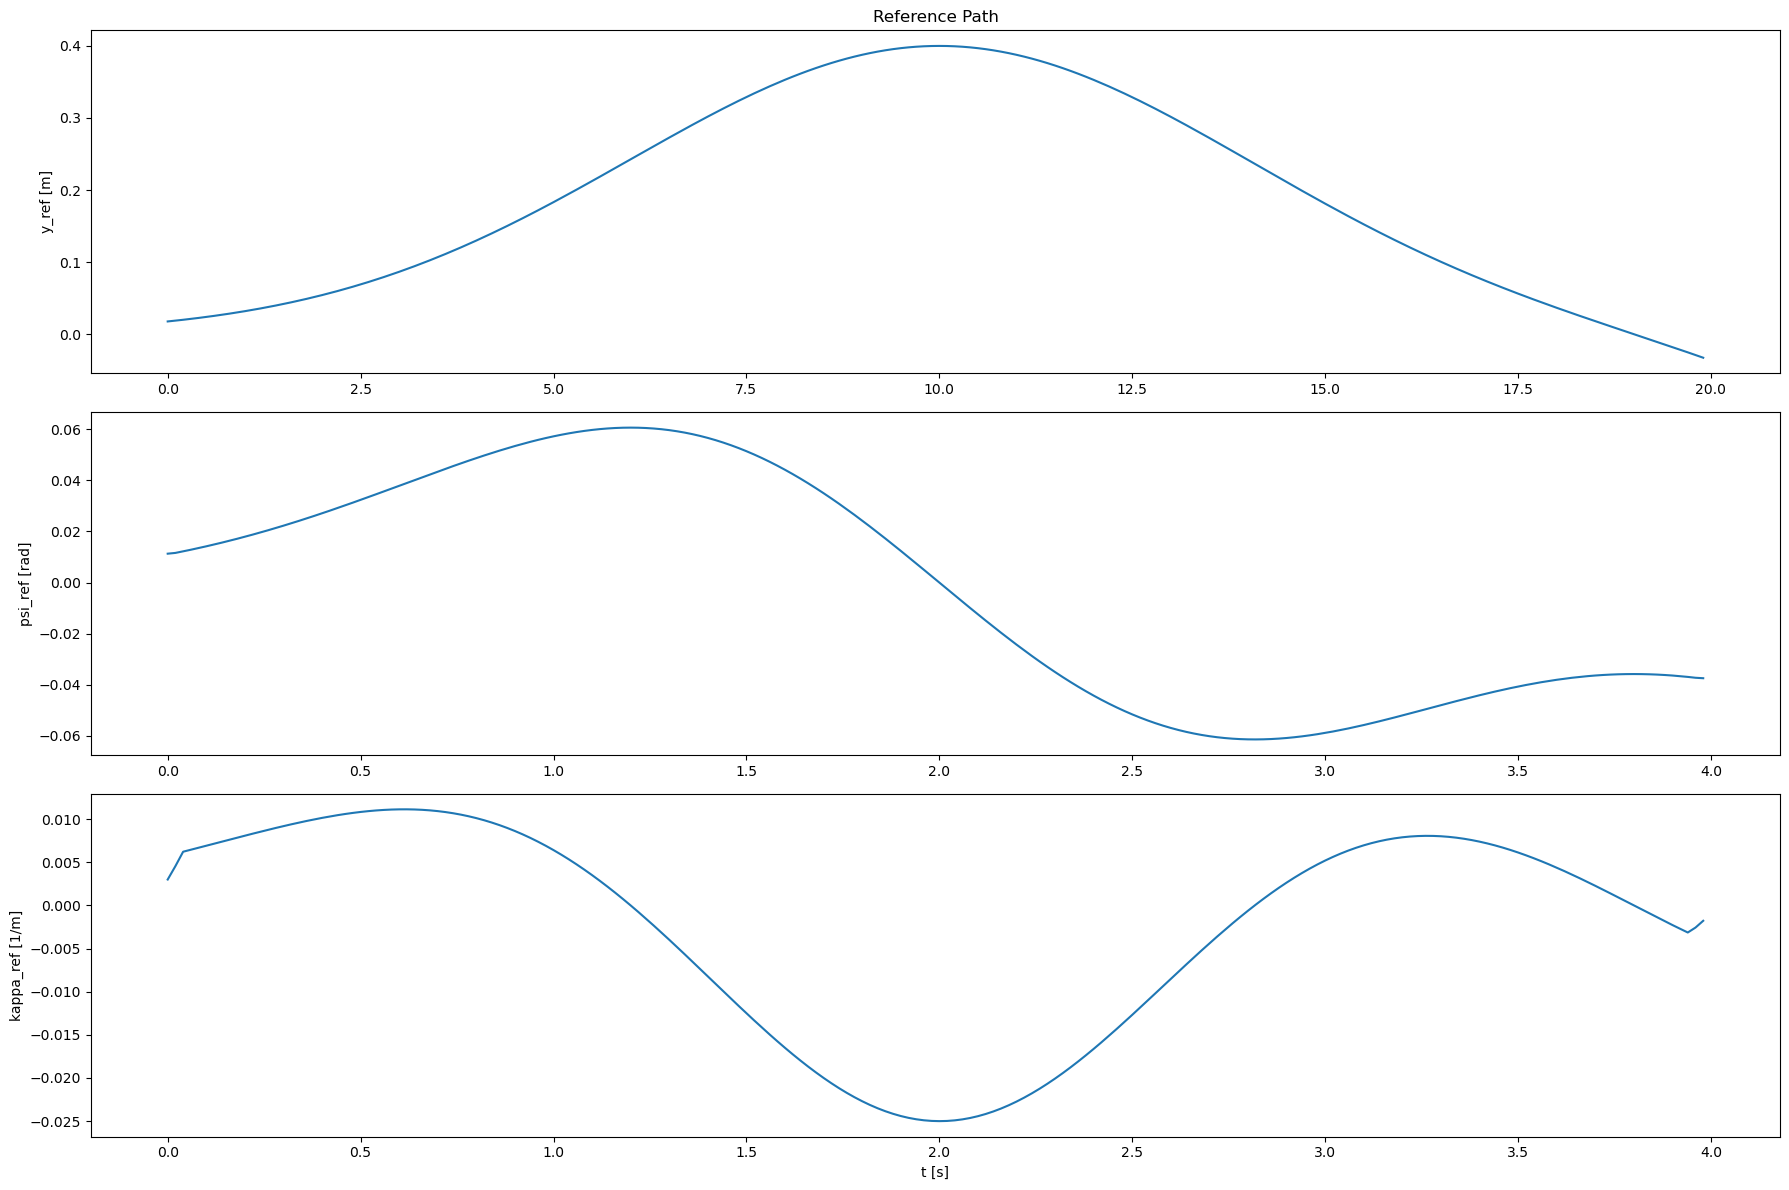

In [29]:
import scipy
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics

T_traj = 4.0
t_ref = np.arange(0, T_traj, dt)
traj_length = t_ref.size

vx_nom = sys_pars['vx_ref']
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 10.0
x2 = 28.0
sigma1 = 4.0
sigma2 = 4.0

y_ref_path = (
    A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
    + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

dy_dx = np.gradient(y_ref_path, x_path)
psi_ref_path = np.arctan(dy_dx)
curvature_ref_path = np.gradient(psi_ref_path, x_path)
curvature_ref_path = np.nan_to_num(curvature_ref_path)

# 误差模型参考：目标是误差收敛到 0
x_ref = np.zeros((num_states, traj_length))

plt.figure(figsize=(18, 12))
plt.subplot(3,1,1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3,1,2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3,1,3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")

plt.tight_layout()
plt.show()

In [30]:
"""tracking without adaptation (use stable-projected A)"""
begin_linear_noadapt = time.time()

def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.array(x)

# Koopman matrices
A_lin = to_numpy(model_koop_dnn_lin.A)
B_lin = to_numpy(model_koop_dnn_lin.B)
C_lin = to_numpy(model_koop_dnn_lin.C)

# ===== stable projection of A =====
eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([ev / max(1.0, np.abs(ev)) * 0.999 for ev in eigvals])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

# ===== OSQP solver settings =====
solver_settings = {}
solver_settings['gen_embedded_ctrl'] = False
solver_settings['warm_start'] = True
solver_settings['polish'] = True
solver_settings['polish_refine_iter'] = 6
solver_settings['scaling'] = True
solver_settings['adaptive_rho'] = True
solver_settings['check_termination'] = 25
solver_settings['max_iter'] = 10000
solver_settings['eps_abs'] = 1e-5
solver_settings['eps_rel'] = 1e-5
solver_settings['eps_prim_inf'] = 1e-4
solver_settings['eps_dual_inf'] = 1e-4

# ===== MPC horizon =====
N_lin_noadapt = 15


x_ref_mpc = np.hstack((
    x_ref,
    np.tile(x_ref[:, -1].reshape(-1, 1), N_lin_noadapt + 1)
))

# ===== cost matrices =====

Q_mpc_lin_noadapt = 10 * scipy.sparse.diags([20, 20, 5, 5, 10])
QN_mpc_lin_noadapt = 15 * scipy.sparse.diags([20, 20, 5, 5, 10])



R_mpc_lin_noadapt = scipy.sparse.diags([10, 5])
R0_mpc_lin_noadapt = scipy.sparse.csc_matrix(np.zeros(num_inputs))

max_iter_lin = 5

# ===== state and input constraints =====

xmax_lin_noadapt = np.array([10.0, 10.0, 10.0, 10.0, 10.0])
xmin_lin_noadapt = -xmax_lin_noadapt
# 和你当前训练数据一致的输入限幅

umax_lin_noadapt = np.array([0.08, 1.0])
umin_lin_noadapt = -umax_lin_noadapt
# ===== closed-loop arrays =====
xt_actual_lin_noadapt = np.zeros((traj_length, num_states))

# 小初值误差，先做保守验证

xt_actual_lin_noadapt[0, :] = np.zeros(num_states)

u_lin_noadapt = np.zeros((traj_length - 1, num_inputs))
z_lin_noadapt = np.zeros((traj_length, n_obs_lin))

# ===== initial guess for MPC =====
x_init_lin_noadapt = np.tile(xt_actual_lin_noadapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_noadapt = np.zeros((N_lin_noadapt, num_inputs))

n_lift = A_lin_stable.shape[0]
z_init_lin_noadapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    z_init_lin_noadapt[ii, :] = lift_raw(
        x_init_lin_noadapt[ii, :],
        model_koop_dnn_lin,
        net_params_lin
    )

# ===== use stable-projected A for control model =====
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

controller_nmpc_lin_noadapt = NonlinearMPCController(
    linear_model_no_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

controller_nmpc_lin_noadapt.construct_controller(
    z_init_lin_noadapt,
    u_init_lin_noadapt,
    x_ref[:, 0]
)

time_excess = 0.0
# time_excess = 0.0

for k in range(traj_length - 1):
    z_lin_noadapt[k, :] = lift_raw(
        xt_actual_lin_noadapt[k, :],
        model_koop_dnn_lin,
        net_params_lin
    )

    controller_nmpc_lin_noadapt.solve_to_convergence(
        x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2],
        z_lin_noadapt[k, :],
        controller_nmpc_lin_noadapt.z_init,
        controller_nmpc_lin_noadapt.u_init,
        max_iter=max_iter_lin,
        eps=1e-3
    )

    controller_nmpc_lin_noadapt.update_initial_guess_()

    # ===== steering feedforward from road curvature =====
    delta_fb_mpc = controller_nmpc_lin_noadapt.cur_u[0, 0]
    ax_cmd = controller_nmpc_lin_noadapt.cur_u[0, 1]

    delta_ff = 0.8 * (sys_pars['lf'] + sys_pars['lr']) * curvature_ref_path[k]
    delta_cmd = delta_fb_mpc + delta_ff

    u_lin_noadapt[k, 0] = np.clip(delta_cmd, umin_lin_noadapt[0], umax_lin_noadapt[0])
    u_lin_noadapt[k, 1] = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    sys_pars_new_step = dict(sys_pars_new)
    sys_pars_new_step['curvature_ref'] = curvature_ref_path[k]

    t1 = time.time()

    xt_actual_lin_noadapt[k + 1, :] = FK_solver(
        xt_actual_lin_noadapt[k, :],
        u_lin_noadapt[k, :],
        sys_pars_new_step,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )

    t2 = time.time()
    time_excess += (t2 - t1)


end_linear_noadapt = time.time()
time_linear_noadapt = (end_linear_noadapt - begin_linear_noadapt - time_excess) / traj_length

print("Average MPC solve time per step =", time_linear_noadapt)

stable spectral radius = 0.9990002


E:\anaconda\envs\pytorch_new\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


Average MPC solve time per step = 0.0060079371929168705


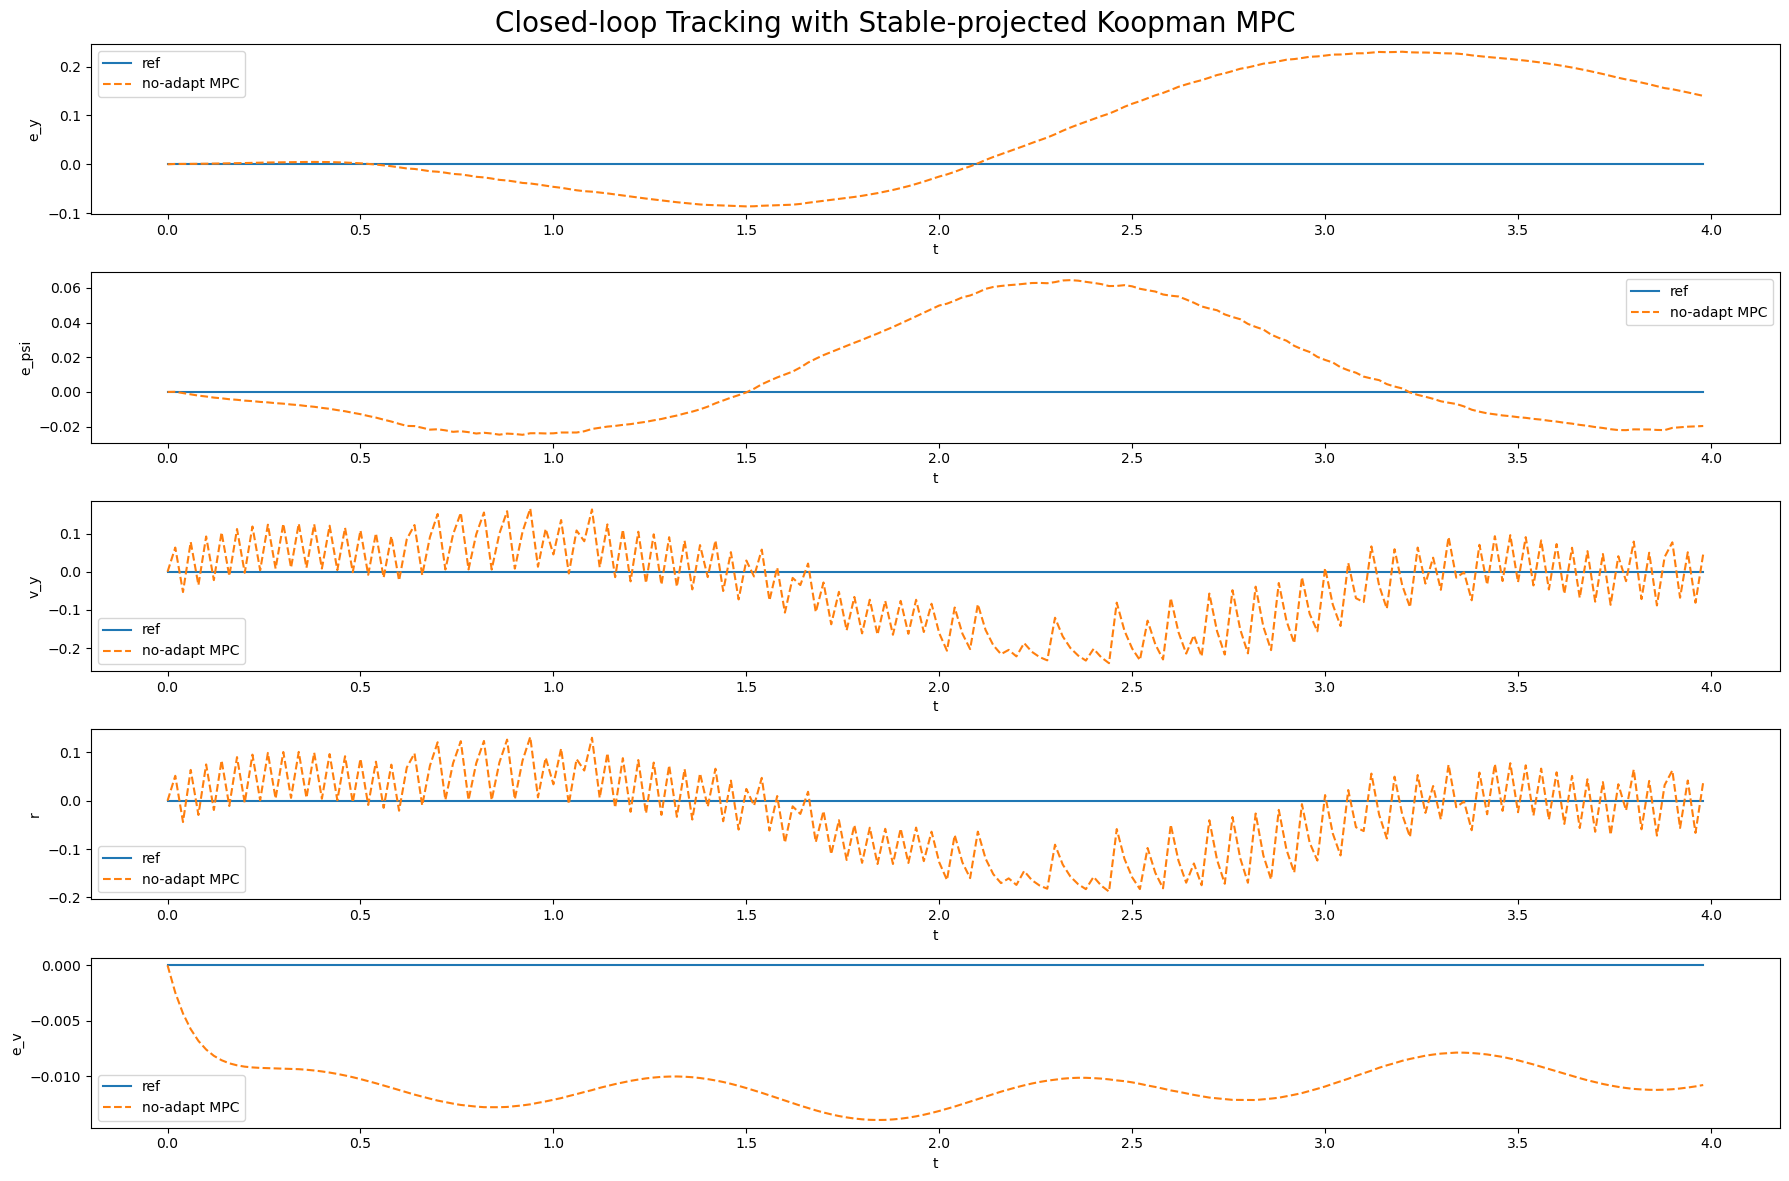

In [31]:
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :], label='ref')
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], '--', label='no-adapt MPC')
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking with Stable-projected Koopman MPC", fontsize=20)
plt.tight_layout()
plt.show()

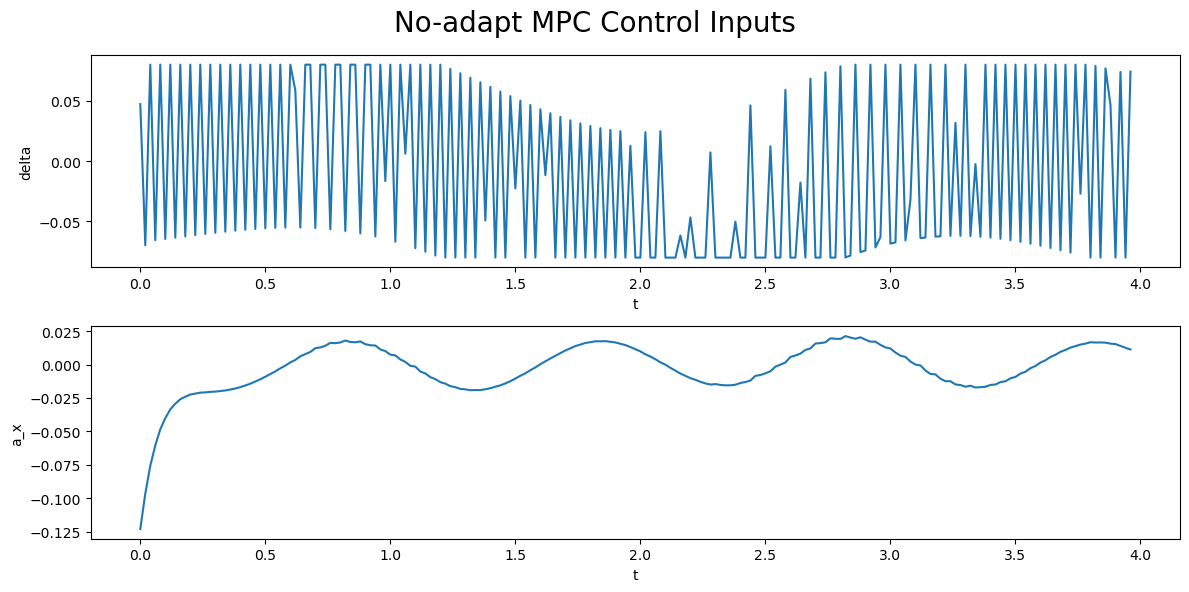

In [32]:
plt.figure(figsize=(12, 6))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    plt.plot(t_ref[:-1], u_lin_noadapt[:, i])
    plt.ylabel(input_labels[i])
    plt.xlabel("t")

plt.suptitle("No-adapt MPC Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

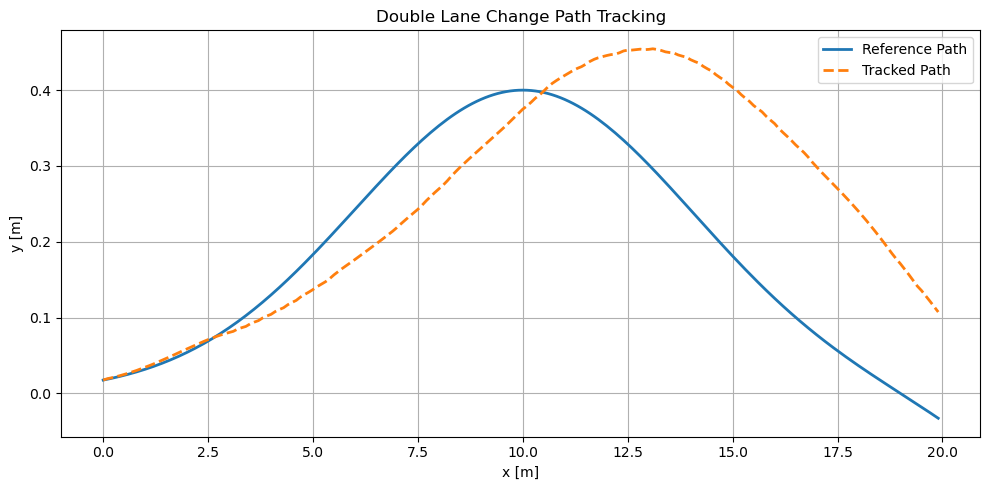

In [33]:
x_actual_path = x_path
y_actual_path = y_ref_path + xt_actual_lin_noadapt[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_ref_path, label='Reference Path', linewidth=2)
plt.plot(x_actual_path, y_actual_path, '--', label='Tracked Path', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Double Lane Change Path Tracking')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

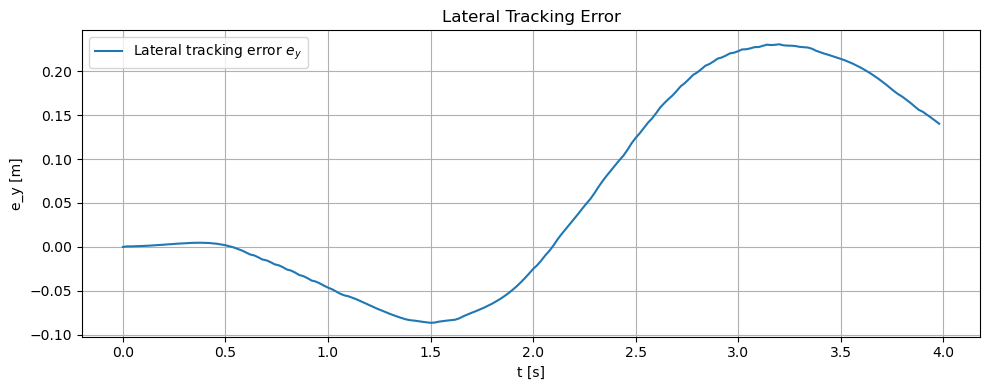

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 0], label='Lateral tracking error $e_y$')
plt.xlabel('t [s]')
plt.ylabel('e_y [m]')
plt.title('Lateral Tracking Error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 自适应abc

In [35]:
adapt_window_ctrl_lin = 25
forget_f = 0.98

adapt_params_control_lin = {}
adapt_params_control_lin['state_dim'] = num_states
adapt_params_control_lin['ctrl_dim'] = num_inputs
adapt_params_control_lin['lift_dim'] = net_params_lin["encoder_output_dim"]
adapt_params_control_lin['optimizer'] = 'adam'
adapt_params_control_lin['lr'] = 1e-4
adapt_params_control_lin['epochs'] = 5
adapt_params_control_lin['batch_size'] = adapt_window_ctrl_lin
adapt_params_control_lin['l2_reg'] = 1e-5
adapt_params_control_lin['l1_reg'] = 1e-7
adapt_params_control_lin['state_loss_coeff'] = 1.0
adapt_params_control_lin['first_obs_const'] = net_params_lin["first_obs_const"]
adapt_params_control_lin['override_C'] = net_params_lin["override_C"]
adapt_params_control_lin['warm_start'] = False

In [36]:
A_base = A_lin_stable.copy()
B_base = B_lin.copy()
C_base = C_lin.copy()

In [37]:
linear_model_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_base),
    scipy.sparse.csc_matrix(B_base),
    C_base
)

controller_nmpc_adapt = NonlinearMPCController(
    linear_model_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

In [38]:
xt_actual_lin_adapt = np.zeros((traj_length, num_states))
xt_actual_lin_adapt[0, :] = np.zeros(num_states)

u_lin_adapt = np.zeros((traj_length - 1, num_inputs))
z_lin_adapt = np.zeros((traj_length, n_obs_lin))

x_init_lin_adapt = np.tile(xt_actual_lin_adapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_adapt = np.zeros((N_lin_noadapt, num_inputs))
z_init_lin_adapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    z_init_lin_adapt[ii, :] = lift_raw(
        x_init_lin_adapt[ii, :],
        model_koop_dnn_lin,
        net_params_lin
    )

controller_nmpc_adapt.construct_controller(
    z_init_lin_adapt,
    u_init_lin_adapt,
    x_ref[:, 0]
)

In [39]:
del_A_ctrl_lin = np.zeros_like(A_base)
del_B_ctrl_lin = np.zeros_like(B_base)

del_A_norm_ctrl_lin = np.zeros(traj_length)
del_B_norm_ctrl_lin = np.zeros(traj_length)

# A_adapt_prev = A_base.copy()
# B_adapt_prev = B_base.copy()
#
# del_A_ctrl_lin_prev = np.zeros_like(A_base)
# del_B_ctrl_lin_prev = np.zeros_like(B_base)
#
# beta_adapt = 0.8

In [40]:
begin_linear_adapt = time.time()
time_excess_adapt = 0.0

for k in range(traj_length - 1):
    z_lin_adapt[k, :] = lift_raw(
        xt_actual_lin_adapt[k, :],
        model_koop_dnn_lin,
        net_params_lin
    )

    # ===== online adaptation =====
    if k < adapt_window_ctrl_lin:
        del_A_ctrl_lin = np.zeros_like(A_base)
        del_B_ctrl_lin = np.zeros_like(B_base)
    else:
        if k == adapt_window_ctrl_lin:
            print("Entered adaptation branch at k =", k)

        Z_obs = []
        U_obs = []
        del_Z_prime = []

        for j in range(adapt_window_ctrl_lin):
            idx = k - adapt_window_ctrl_lin + j

            z_k_hist = z_lin_adapt[idx, :]
            z_kp1_hist = z_lin_adapt[idx + 1, :]
            u_k_hist = u_lin_adapt[idx, :]

            z_pred_base = A_base @ z_k_hist + B_base @ u_k_hist

            # z_pred_base = A_adapt_prev @ z_k_hist + B_adapt_prev @ u_k_hist
            weight = forget_f ** (adapt_window_ctrl_lin - j - 1)

            Z_obs.append(z_k_hist)
            U_obs.append(u_k_hist)
            del_Z_prime.append(weight * (z_kp1_hist - z_pred_base))

        Z_obs = np.array(Z_obs).T
        U_obs = np.array(U_obs).T
        del_Z_prime = np.array(del_Z_prime).T
        if k in [adapt_window_ctrl_lin, adapt_window_ctrl_lin + 1, 50]:
            print(f"k={k}")
            print("||Z_obs|| =", np.linalg.norm(Z_obs))
            print("||U_obs|| =", np.linalg.norm(U_obs))
            print("||del_Z_prime|| =", np.linalg.norm(del_Z_prime))
        # adapt_network = AdaptNet_linear(adapt_params_control_lin)
        # adapt_network.model_pipeline(
        #     Z_obs,
        #     U_obs,
        #     del_Z_prime,
        #     print_epoch=False
        # )
        #
        # del_A_ctrl_lin, del_B_ctrl_lin = adapt_network.get_del_matrices()
        # adapt_network = AdaptNet_linear(adapt_params_control_lin)
        adapt_network = AdaptNet_linear(adapt_params_control_lin, device=DEVICE)
        adapt_network.model_pipeline(
            Z_obs,
            U_obs,
            del_Z_prime,
            print_epoch=False
        )

        del_A_new, del_B_new = adapt_network.get_del_matrices()

        # del_A_ctrl_lin = del_A_new
        # del_B_ctrl_lin = del_B_new
        alpha_adapt = 0.6

        del_A_ctrl_lin = alpha_adapt * del_A_new
        del_B_ctrl_lin = alpha_adapt * del_B_new

        del_A_max = 0.05
        del_B_max = 0.02

        del_A_ctrl_lin = np.clip(del_A_ctrl_lin, -del_A_max, del_A_max)
        del_B_ctrl_lin = np.clip(del_B_ctrl_lin, -del_B_max, del_B_max)

        # 不自适应 e_v 通道（第 5 个状态，对应索引 4）
        del_A_ctrl_lin[4, :] = 0.0
        del_B_ctrl_lin[4, :] = 0.0

        if k in [adapt_window_ctrl_lin, adapt_window_ctrl_lin + 1, 50]:
            print("||del_A_ctrl_lin|| =", np.linalg.norm(del_A_ctrl_lin))
            print("||del_B_ctrl_lin|| =", np.linalg.norm(del_B_ctrl_lin))

        # del_A_ctrl_lin = beta_adapt * del_A_ctrl_lin_prev + (1.0 - beta_adapt) * del_A_new
        # del_B_ctrl_lin = beta_adapt * del_B_ctrl_lin_prev + (1.0 - beta_adapt) * del_B_new


    del_A_norm_ctrl_lin[k] = np.linalg.norm(del_A_ctrl_lin)
    del_B_norm_ctrl_lin[k] = np.linalg.norm(del_B_ctrl_lin)

    A_adapt = A_base + del_A_ctrl_lin
    B_adapt = B_base + del_B_ctrl_lin

    linear_model_adapt.A = scipy.sparse.csc_matrix(A_adapt)
    linear_model_adapt.B = scipy.sparse.csc_matrix(B_adapt)

    # A_adapt_prev = A_adapt.copy()
    # B_adapt_prev = B_adapt.copy()
    #
    # del_A_ctrl_lin_prev = del_A_ctrl_lin.copy()
    # del_B_ctrl_lin_prev = del_B_ctrl_lin.copy()

    controller_nmpc_adapt.solve_to_convergence(
        x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2],
        z_lin_adapt[k, :],
        controller_nmpc_adapt.z_init,
        controller_nmpc_adapt.u_init,
        max_iter=max_iter_lin,
        eps=1e-3
    )

    controller_nmpc_adapt.update_initial_guess_()

    # ===== steering feedforward =====
    delta_fb_mpc = controller_nmpc_adapt.cur_u[0, 0]
    ax_cmd = controller_nmpc_adapt.cur_u[0, 1]

    delta_ff = 0.8 * (sys_pars['lf'] + sys_pars['lr']) * curvature_ref_path[k]
    delta_cmd = delta_fb_mpc + delta_ff

    u_lin_adapt[k, 0] = np.clip(delta_cmd, umin_lin_noadapt[0], umax_lin_noadapt[0])
    u_lin_adapt[k, 1] = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

    sys_pars_new_step = dict(sys_pars_new)
    sys_pars_new_step['curvature_ref'] = curvature_ref_path[k]

    t1 = time.time()

    xt_actual_lin_adapt[k + 1, :] = FK_solver(
        xt_actual_lin_adapt[k, :],
        u_lin_adapt[k, :],
        sys_pars_new_step,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )

    t2 = time.time()
    time_excess_adapt += (t2 - t1)

end_linear_adapt = time.time()
time_linear_adapt = (end_linear_adapt - begin_linear_adapt - time_excess_adapt) / traj_length

print("Average adaptive MPC solve time per step =", time_linear_adapt)

Entered adaptation branch at k = 25
k=25
||Z_obs|| = 10.363691018352513
||U_obs|| = 0.41308764709013485
||del_Z_prime|| = 7.641622573686521
||del_A_ctrl_lin|| = 0.0049235127
||del_B_ctrl_lin|| = 0.0014793533
k=26
||Z_obs|| = 10.650328563120919
||U_obs|| = 0.39645779629721334
||del_Z_prime|| = 7.520732780628546
||del_A_ctrl_lin|| = 0.0049077217
||del_B_ctrl_lin|| = 0.0014846431
k=50
||Z_obs|| = 12.457042689775298
||U_obs|| = 0.4646668318404879
||del_Z_prime|| = 7.532142010513653
||del_A_ctrl_lin|| = 0.0049115783
||del_B_ctrl_lin|| = 0.001491098
Average adaptive MPC solve time per step = 0.01508401393890381


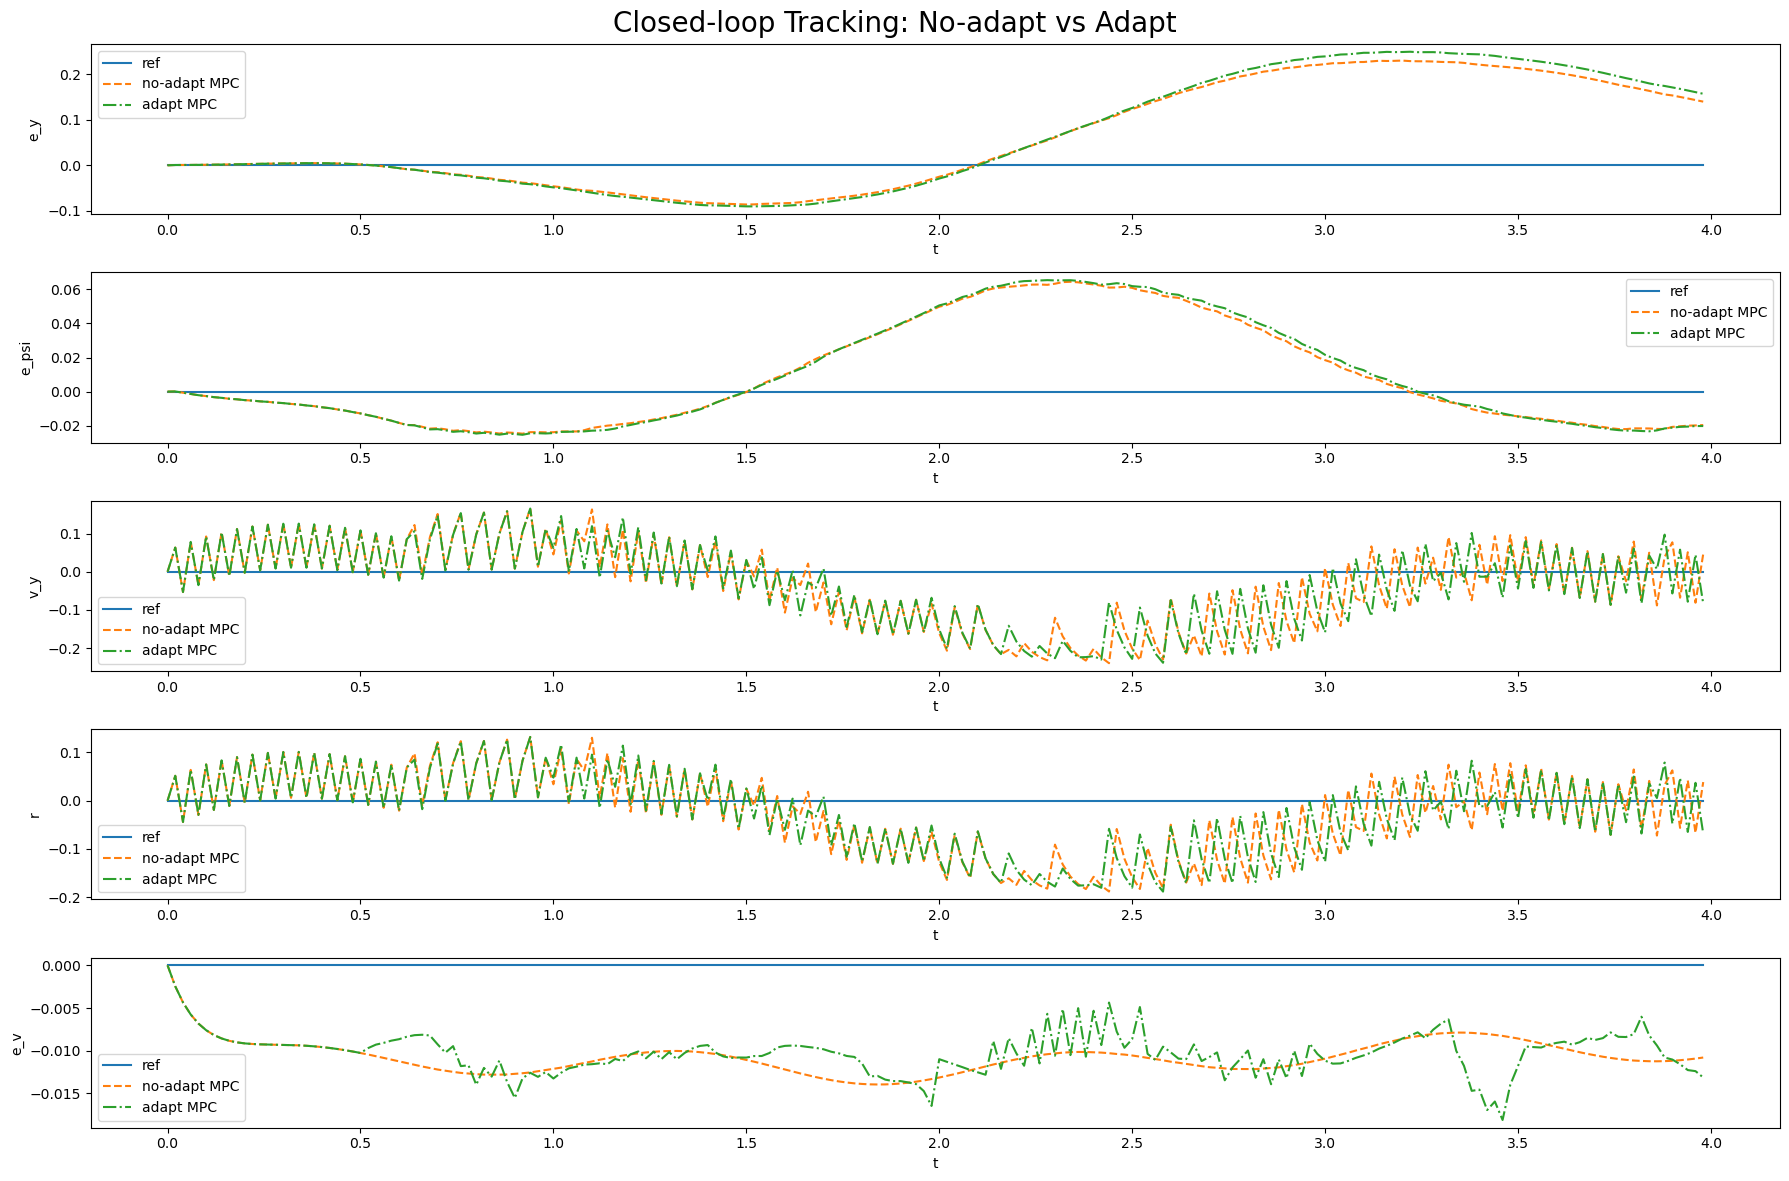

In [41]:
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :], label='ref')
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], '--', label='no-adapt MPC')
    plt.plot(t_ref, xt_actual_lin_adapt[:, i], '-.', label='adapt MPC')
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking: No-adapt vs Adapt", fontsize=20)
plt.tight_layout()
plt.show()

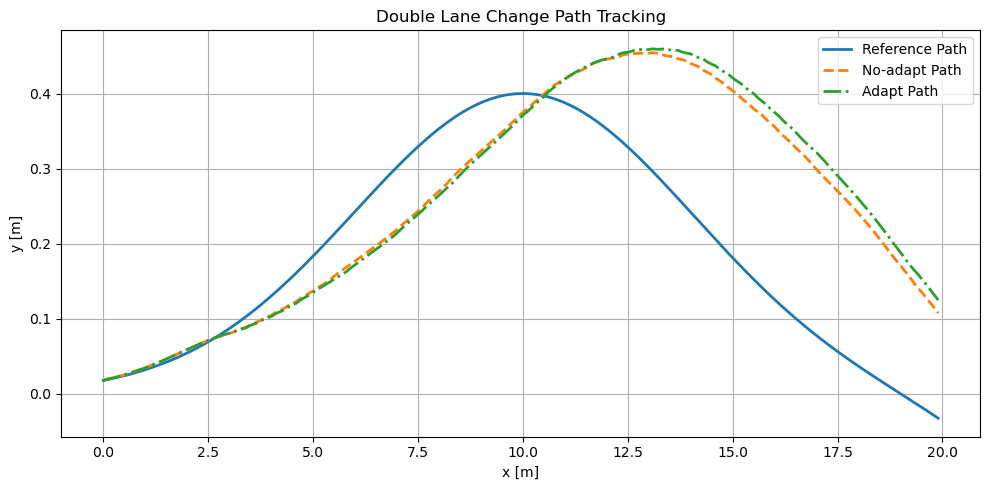

In [42]:
x_actual_path_noadapt = x_path
y_actual_path_noadapt = y_ref_path + xt_actual_lin_noadapt[:, 0]

x_actual_path_adapt = x_path
y_actual_path_adapt = y_ref_path + xt_actual_lin_adapt[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(x_path, y_ref_path, label='Reference Path', linewidth=2)
plt.plot(x_actual_path_noadapt, y_actual_path_noadapt, '--', label='No-adapt Path', linewidth=2)
plt.plot(x_actual_path_adapt, y_actual_path_adapt, '-.', label='Adapt Path', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Double Lane Change Path Tracking')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

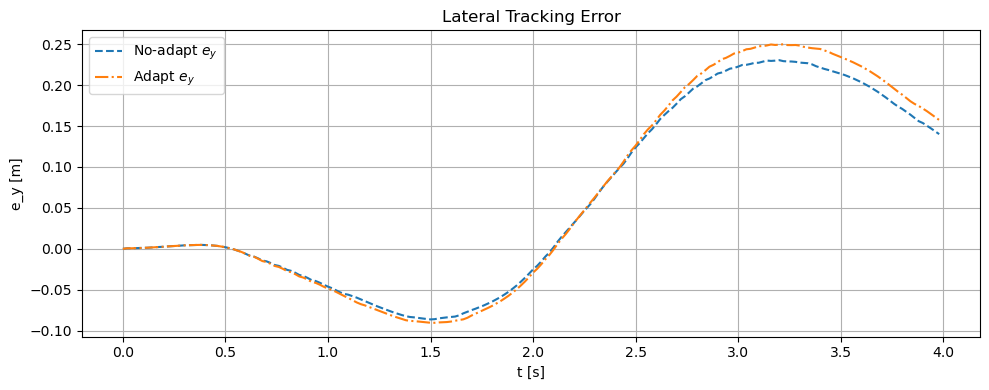

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 0], '--', label='No-adapt $e_y$')
plt.plot(t_ref, xt_actual_lin_adapt[:, 0], '-.', label='Adapt $e_y$')
plt.xlabel('t [s]')
plt.ylabel('e_y [m]')
plt.title('Lateral Tracking Error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

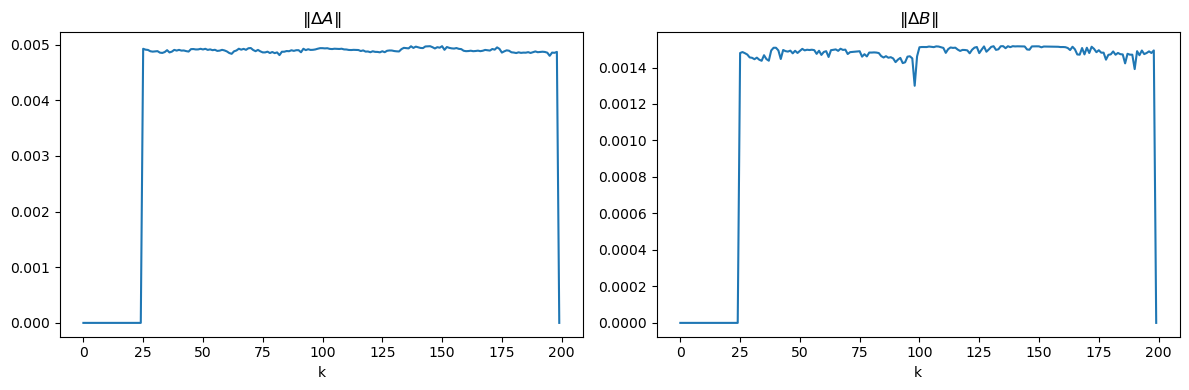

In [44]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(del_A_norm_ctrl_lin)
plt.title(r'$\|\Delta A\|$')
plt.xlabel('k')

plt.subplot(1, 2, 2)
plt.plot(del_B_norm_ctrl_lin)
plt.title(r'$\|\Delta B\|$')
plt.xlabel('k')

plt.tight_layout()
plt.show()